<center><h1>HW5</h1></center>
<br>
<br>

Name: xxx
<br>
Github Username: xxx
<br>
USC ID: xxx

## 1. Decision Trees as Interpretable Models

Import packages

In [18]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EmpiricalCovariance
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy.stats import bootstrap
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc as sklearn_auc
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn import tree
from sklearn.tree import _tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

### (a) Obtain Data

Get the Accute Inamations Data Set

In [2]:
data = pd.read_csv('../Data/diagnosis.data',encoding='utf-16',sep=r'\s+',decimal=',')
data.columns = [
    'Temperature of patient',
    'Occurrence of nausea',
    'Lumbar pain',
    'Urine pushing (continuous need for urination)',
    'Micturition pains',
    'Burning of urethra, itch, swelling of urethra outlet',
    'Inflammation of urinary bladder',
    'Nephritis of renal pelvis origin'
]
data = data.apply(lambda col: col.map(lambda x: 1 if str(x).strip().lower() == 'yes'
                                      else (0 if str(x).strip().lower() == 'no' else x)))

data.head()

,Temperature of patient,Occurrence of nausea,Lumbar pain,Urine pushing (continuous need for urination),Micturition pains,"Burning of urethra, itch, swelling of urethra outlet",Inflammation of urinary bladder,Nephritis of renal pelvis origin
0,35.9,0,0,1,1,1,1,0
1,35.9,0,1,0,0,0,0,0
2,36.0,0,0,1,1,1,1,0
3,36.0,0,1,0,0,0,0,0
4,36.0,0,1,0,0,0,0,0


### (b) Build a decision tree

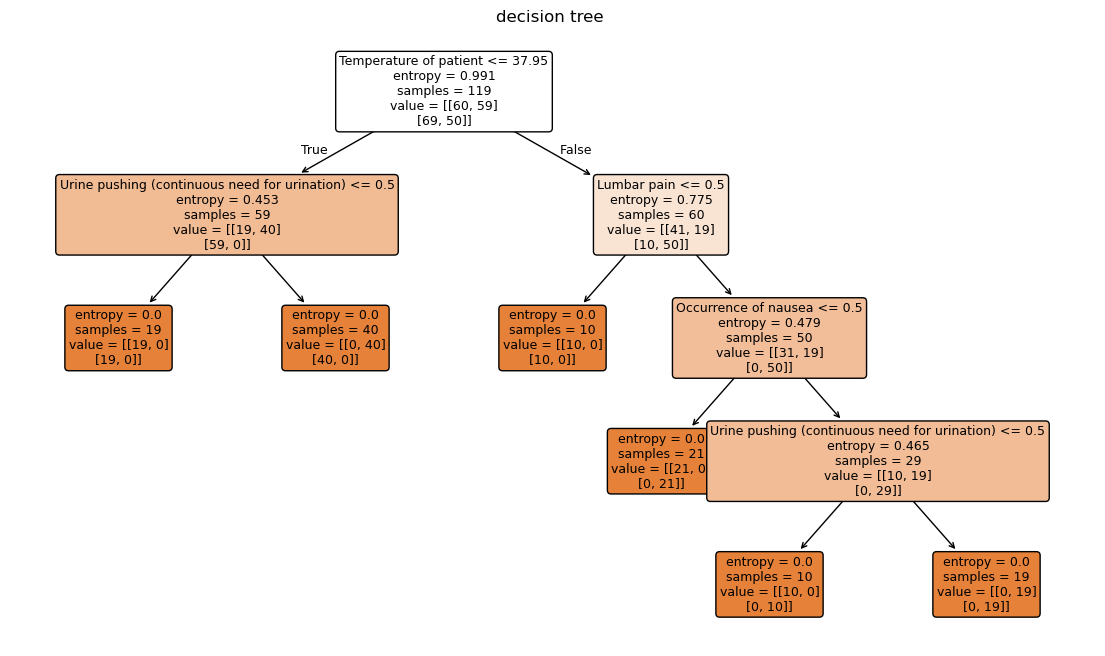

In [3]:
##data set
X = data.iloc[:,:-2]
Y = data.iloc[:,-2:]
tre = tree.DecisionTreeClassifier(criterion='entropy', random_state=42,)
tre.fit(X,Y)

#model1
plt.figure(figsize=(14, 8))
tree.plot_tree(
    tre,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("decision tree ")
plt.show()


### (c) Convert the decision rules

In [4]:

def tree_to_rules_multioutput(decision_tree, feature_names, target_names):
    tree_ = decision_tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    rules = []
    def recurse(node, depth, path_conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], depth+1,
                    path_conditions + [f"{name} ≤ {threshold:.3f}"])
            recurse(tree_.children_right[node], depth+1,
                    path_conditions + [f"{name} > {threshold:.3f}"])
        else:
            values = tree_.value[node][0]
            outputs = []
            for i, t in enumerate(target_names):
                outputs.append(f"{t} = {'Yes' if values[i] >= 0.5 else 'No'}")
            rule = "IF " + " AND ".join(path_conditions) + " THEN " + ", ".join(outputs)
            rules.append(rule)
    recurse(0, 1, [])
    return rules
feature_names = list(X.columns)
target_names = list(Y.columns)
rules = tree_to_rules_multioutput(tre, feature_names, target_names)
for i, r in enumerate(rules[:10]):
    print(f"Rule {i+1}: {r}")


Rule 1: IF Temperature of patient ≤ 37.950 AND Urine pushing (continuous need for urination) ≤ 0.500 THEN Inflammation of urinary bladder = Yes, Nephritis of renal pelvis origin = No
Rule 2: IF Temperature of patient ≤ 37.950 AND Urine pushing (continuous need for urination) > 0.500 THEN Inflammation of urinary bladder = No, Nephritis of renal pelvis origin = Yes
Rule 3: IF Temperature of patient > 37.950 AND Lumbar pain ≤ 0.500 THEN Inflammation of urinary bladder = Yes, Nephritis of renal pelvis origin = No
Rule 4: IF Temperature of patient > 37.950 AND Lumbar pain > 0.500 AND Occurrence of nausea ≤ 0.500 THEN Inflammation of urinary bladder = Yes, Nephritis of renal pelvis origin = No
Rule 5: IF Temperature of patient > 37.950 AND Lumbar pain > 0.500 AND Occurrence of nausea > 0.500 AND Urine pushing (continuous need for urination) ≤ 0.500 THEN Inflammation of urinary bladder = Yes, Nephritis of renal pelvis origin = No
Rule 6: IF Temperature of patient > 37.950 AND Lumbar pain > 0.

### (d) Use cost-complexity pruning to find a minimal decision tree and a set of decision rules with high interpretability.

In [5]:
path = tre.cost_complexity_pruning_path(X, Y)
ccp_alphas = path.ccp_alphas
tres = []
for ccp_alpha in ccp_alphas:
    tre = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, ccp_alpha=ccp_alpha)
    tre.fit(X, Y)
    tres.append(tre)
resulttree = next(c for c in reversed(tres) if c.tree_.node_count > 1)
rules = tree_to_rules_multioutput(resulttree, feature_names, target_names)

print(f"Number of rules after pruning: {len(rules)}")
for i, r in enumerate(rules):
    print(f"Pruned Rule {i+1}: {r}")


Number of rules after pruning: 2
Pruned Rule 1: IF Temperature of patient ≤ 37.950 THEN Inflammation of urinary bladder = No, Nephritis of renal pelvis origin = Yes
Pruned Rule 2: IF Temperature of patient > 37.950 THEN Inflammation of urinary bladder = Yes, Nephritis of renal pelvis origin = No


## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [6]:
data = pd.read_csv('../Data/communities.data')
data.columns = [f'col_{i}' for i in range(data.shape[1])]
traindt = data[:1495]
testdt = data[1495:]
traindt

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_118,col_119,col_120,col_121,col_122,col_123,col_124,col_125,col_126,col_127
0,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
1,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
2,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
3,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
4,6,?,?,SouthPasadenacity,1,0.02,0.28,0.06,0.54,1.00,...,0.01,0.58,0.10,?,?,?,?,0.00,?,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,6,?,?,Orangecity,8,0.16,0.62,0.03,0.74,0.48,...,0.07,0.40,0.14,0.07,0.05,0.85,0.5,0.61,0.19,0.20
1491,13,?,?,Waycrosscity,8,0.01,0.36,0.95,0.24,0.03,...,0.03,0.12,0.01,?,?,?,?,0.00,?,0.30
1492,39,85,49056,Mentorcity,8,0.06,0.53,0.01,0.98,0.05,...,0.08,0.15,0.02,?,?,?,?,0.00,?,0.03
1493,34,17,79610,WestNewYorktown,8,0.05,0.43,0.08,0.65,0.12,...,0.00,1.00,1.00,0,0.01,0.77,0,0.51,0.18,0.23


### (b) Missing values

In [ ]:


#missing value
nonpred = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4']
pred =  [c for c in data.columns if c not in nonpred]
data.replace('?', np.nan, inplace=True)
data[pred] = data[pred].astype(float)
imputer = SimpleImputer(strategy='mean')
data[pred] = imputer.fit_transform(data[pred])

#train test
traindt = data[:1495]
testdt = data[1495:]

### (c) Plot a correlation matrix

In [8]:
ma = data[pred].corr()
print(ma)

            col_5     col_6     col_7     col_8     col_9    col_10    col_11  \
col_5    1.000000 -0.045742  0.231594 -0.301269  0.181738  0.156202  0.006654   
col_6   -0.045742  1.000000 -0.067385 -0.235722  0.201965  0.468785  0.520365   
col_7    0.231594 -0.067385  1.000000 -0.794350 -0.106800 -0.066552  0.122188   
col_8   -0.301269 -0.235722 -0.794350  1.000000 -0.270243 -0.444241 -0.193883   
col_9    0.181738  0.201965 -0.106800 -0.270243  1.000000  0.266754 -0.025066   
...           ...       ...       ...       ...       ...       ...       ...   
col_123 -0.061318 -0.005750 -0.081297  0.051510  0.032943  0.024651  0.001270   
col_124  0.076608 -0.000174  0.011220 -0.033448  0.065506  0.025996  0.011369   
col_125  0.466091 -0.094019  0.261174 -0.276603  0.101987  0.125329  0.001558   
col_126 -0.035723 -0.054824  0.021716 -0.005790 -0.011801  0.002146 -0.076827   
col_127  0.367346 -0.034995  0.631279 -0.684787  0.037609  0.293062  0.060438   

           col_12    col_13

### (d) Calculate the Coefficient of Variation CV

In [9]:
means = data[pred].mean()
stds = data[pred].std(ddof=1)
cv = stds / means
cv = cv.sort_values(ascending=False)
cv

col_95     4.406541
col_94     3.486974
col_54     2.995100
col_56     2.901222
col_125    2.558424
             ...   
col_116    0.146003
col_109    0.131346
col_123    0.122302
col_110    0.121635
col_103    0.057141
Length: 123, dtype: float64

### (e) Scatter plots and box plots for highest CV features

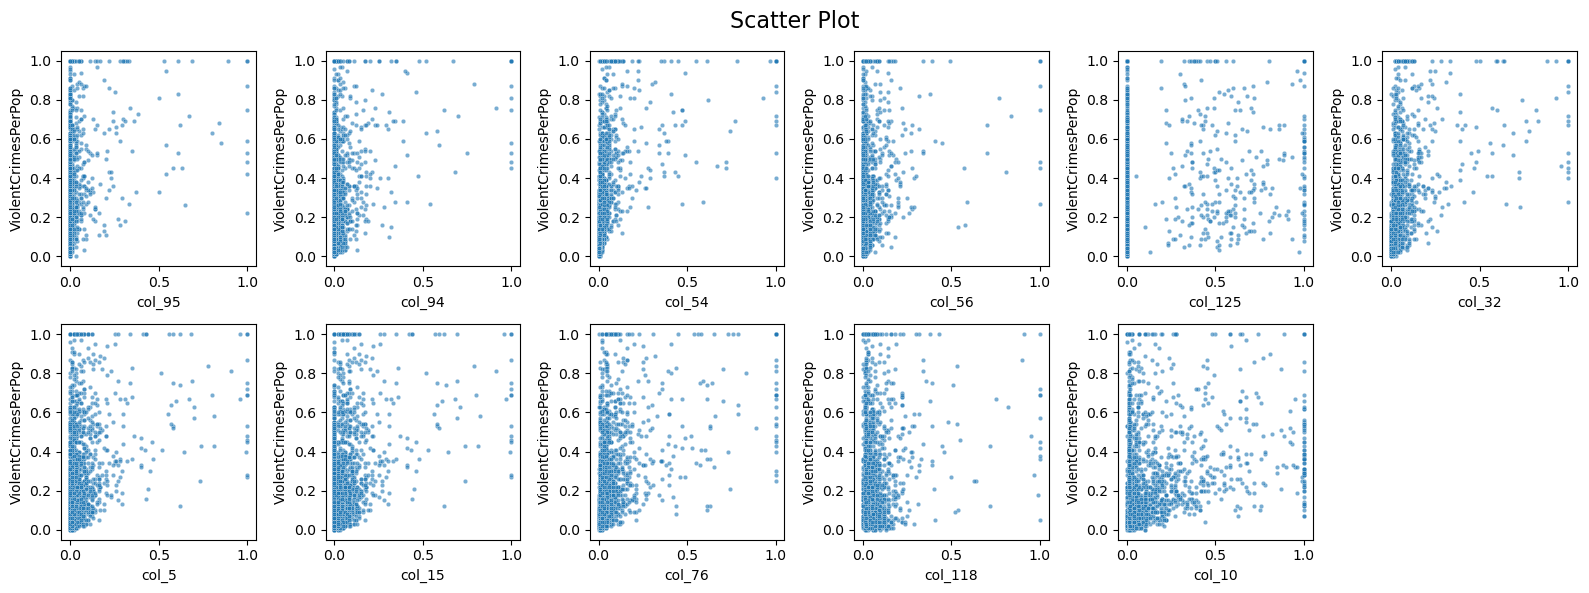

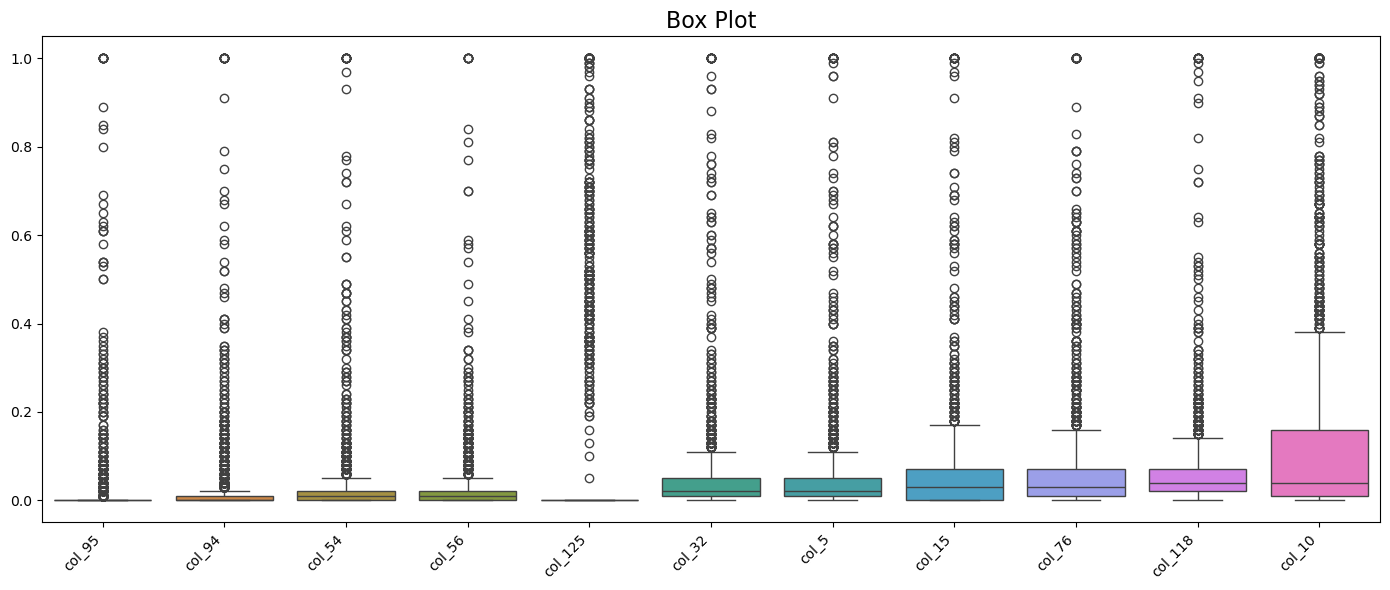

In [10]:
##128**0.5 between 11 and 12, and the floor is 11
top_features = cv.head(11).index.tolist()

plt.figure(figsize=(16, 6))
#scatter
for i, feat in enumerate(top_features):
    plt.subplot(2, len(top_features)//2 + 1, i+1)
    sns.scatterplot(x=data[feat], y=data['col_127'], s=10, alpha=0.6)
    plt.xlabel(feat)
    plt.ylabel('ViolentCrimesPerPop')
plt.suptitle('Scatter Plot', fontsize=16)
plt.tight_layout()
plt.show()

# Box plots
plt.figure(figsize=(14, 6))
sns.boxplot(data=data[top_features])
plt.title('Box Plot', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### answer  
No, cause scatter plot can only depict the very rough trend and distribution, we need to use professional stat indicators to determine significance

### (f) Fit a linear model

In [ ]:

## data set
#already done missing values
target =  ['col_127']
nonpred = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4']
pred =  [c for c in data.columns if c not in nonpred]
pred.remove('col_127')
X_train = traindt[pred]
y_train = traindt[target]
X_test = testdt[pred]
y_test = testdt[target]

#model
model1 = LinearRegression()
model1.fit(X_train,y_train)
yp = model1.predict(X_test)
mse = mean_squared_error(y_test, yp)
print(f'mse is {mse}\n')

mse is 0.7700437743562634



### (g) Fit a ridge regression model

In [ ]:

namudas = np.logspace(-3, 3, 20)

ridge_cv = RidgeCV(alphas=namudas, cv=5)
ridge_cv.fit(X_train, y_train.values.ravel())

bestnamuda = ridge_cv.alpha_
y_pred = ridge_cv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'best namuda: {bestnamuda}')
print(f'Test MSE = {mse:.6f}')
print(f'Test R² = {r2:.6f}')

best namuda: 2.976351441631316
Test MSE = 0.017599
Test R² = 0.630474


### (h) Fit a LASSO model

In [ ]:

#data set
y_train_ = y_train.values.ravel()
y_test_ = y_test.values.ravel()



# not standardized
alphas = np.logspace(-3, 3, 50)
lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=1000)
lasso.fit(X_train, y_train_)

y_pred = lasso.predict(X_test)
mse_unstd = mean_squared_error(y_test_, y_pred)
r2_unstd = r2_score(y_test_, y_pred)

vars = [pred[i] for i, coef in enumerate(lasso.coef_) if coef != 0]

print("no standardization:\n")
print(f"Best λ: {lasso.alpha_:.6f}")
print(f"Test MSE: {mse_unstd:.6f}")
print(f"Test R² : {r2_unstd:.6f}")
print(f"Selected Variables ({len(vars)}): {vars}")

no standardization:

Best λ: 0.001000
Test MSE: 0.017570
Test R² : 0.631082
Selected Variables (23): ['col_7', 'col_8', 'col_12', 'col_16', 'col_22', 'col_29', 'col_43', 'col_49', 'col_50', 'col_53', 'col_55', 'col_64', 'col_73', 'col_76', 'col_77', 'col_79', 'col_91', 'col_93', 'col_95', 'col_96', 'col_99', 'col_124', 'col_125']


In [14]:
#data set
scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.transform(X_test)

#standardization
lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=1000)
lasso.fit(X_train_,y_train_)

yp = lasso.predict(X_test_)
mse = mean_squared_error(y_test_,yp)
r2  = r2_score(y_test_,yp)
vars = [pred[i] for i, coef in enumerate(lasso.coef_) if coef != 0]

print("with standardization:\n")
print(f"Best λ: {lasso.alpha_:.6f}")
print(f"Test MSE: {mse:.6f}")
print(f"Test R² : {r2:.6f}")
print(f"Selected Variables ({len(vars)}): {vars}")



with standardization:

Best λ: 0.001000
Test MSE: 0.017787
Test R² : 0.626534
Selected Variables (68): ['col_7', 'col_11', 'col_12', 'col_16', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30', 'col_31', 'col_33', 'col_34', 'col_38', 'col_39', 'col_43', 'col_44', 'col_45', 'col_49', 'col_50', 'col_51', 'col_53', 'col_54', 'col_55', 'col_56', 'col_58', 'col_64', 'col_66', 'col_68', 'col_72', 'col_73', 'col_74', 'col_76', 'col_77', 'col_79', 'col_80', 'col_81', 'col_83', 'col_87', 'col_90', 'col_91', 'col_92', 'col_93', 'col_94', 'col_95', 'col_96', 'col_99', 'col_104', 'col_105', 'col_107', 'col_109', 'col_111', 'col_112', 'col_113', 'col_115', 'col_116', 'col_117', 'col_118', 'col_119', 'col_120', 'col_121', 'col_123', 'col_124']


### (i) Fit a PCR model

In [ ]:

#data
y_train_ = y_train.values.ravel()
y_test_ = y_test.values.ravel()
scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.transform(X_test)

#pca
maxc = min(X_train_.shape[1],50)
mse_cv = []
for m in range(1,maxc+1):
    pca = PCA(n_components=m)
    X_train_pca = pca.fit_transform(X_train_)
    model = LinearRegression()
    scores = cross_val_score(model,X_train_pca,y_train_,scoring='neg_mean_squared_error',cv=5)
    mse_cv.append(-scores.mean())
bestm = np.argmin(mse_cv) +1 

#model
pca = PCA(n_components=bestm)
X_train_pca = pca.fit_transform(X_train_)
X_test_pca = pca.transform(X_test_)

model = LinearRegression()
model.fit(X_train_pca, y_train_)
y_pred = model.predict(X_test_pca)

mse_test = mean_squared_error(y_test_, y_pred)
r2_test = r2_score(y_test_, y_pred)

print(f"Test MSE = {mse_test:.6f}")
print(f"Test R²  = {r2_test:.6f}")

Test MSE = 0.018253
Test R²  = 0.616746


### (j) Fit a boosting tree

In [ ]:

#data
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()


#cv
param_grid = {
    'reg_alpha': np.logspace(-3, 2, 8)  
}
xgb = XGBRegressor(
    n_estimators=300,          
    learning_rate=0.05,        
    max_depth=4,              
    subsample=0.8,            
    colsample_bytree=0.8,     
    reg_lambda=1.0,           
    random_state=0,
    objective='reg:squarederror'
)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

#model
best_alpha = grid.best_params_['reg_alpha']
best_model = grid.best_estimator_


y_pred = best_model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Test MSE = {mse_test:.6f}")
print(f"Test R²  = {r2_test:.6f}")

Test MSE = 0.015558
Test R²  = 0.673341
